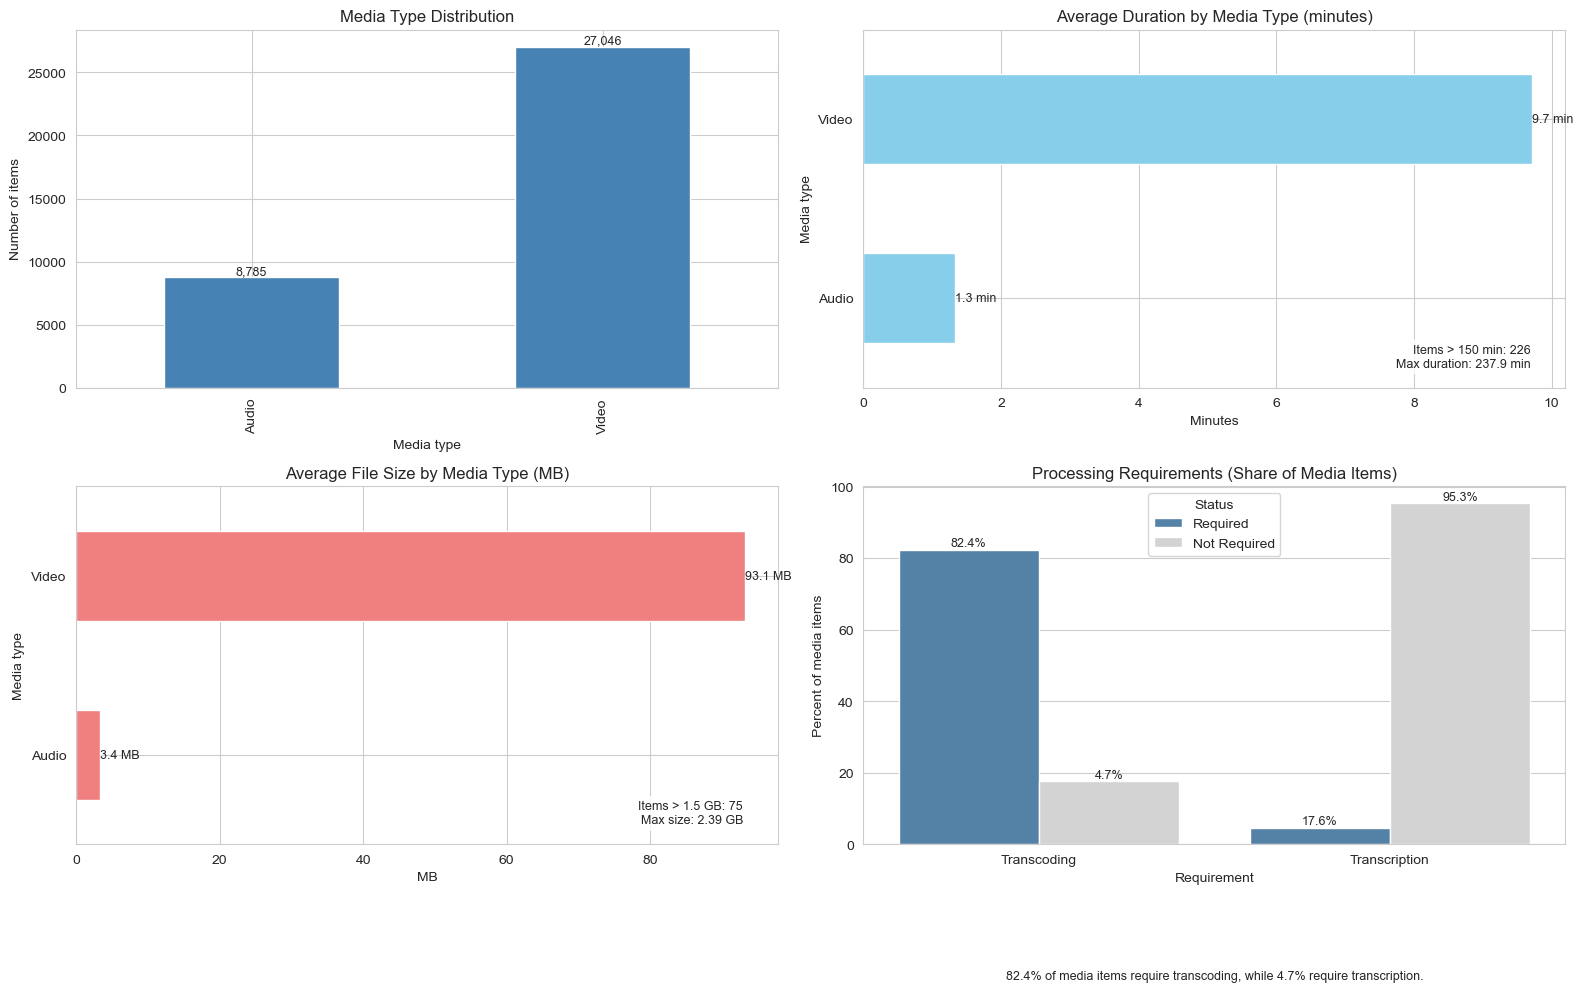

In [2]:
# Imports for data handling, file system access, and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob

# Configure a consistent visual style for all plots in this notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (16, 10)

# ---------------------------------------------------------------------------
# Load Content Service (audio/video) data from the ETL output
# ---------------------------------------------------------------------------
base_path = Path("../etl-output")
content_service_path = base_path / "contentservice/audiovideoprocessed/data"
service_files = sorted(glob.glob(str(content_service_path / "part-*.csv")))

# Combine all part-*.csv files into a single DataFrame of media items
content_service = pd.concat(
    [pd.read_csv(f, low_memory=False) for f in service_files],
    ignore_index=True,
)

# ---------------------------------------------------------------------------
# Precompute summary measures used across multiple plots
# ---------------------------------------------------------------------------
# Count how many items we have of each media type (e.g., Video vs Audio)
media_counts = content_service["type"].value_counts().sort_index()

# Convert raw duration (seconds) and file size (bytes) into more readable units
#  - duration_minutes: used to identify very long videos and for annotations
#  - size_mb: used to identify very large files and for annotations
duration_minutes = content_service.loc[content_service["duration"] > 0, "duration"] / 60
size_mb = content_service["revision_size"] / (1024 * 1024)

# Average duration (in minutes) by media type, sorted so bars read left-to-right
avg_duration_by_type = (
    content_service.loc[content_service["duration"] > 0]
    .groupby("type")["duration"]
    .mean()
    .sort_values()
    / 60
)

# Average file size (in MB) by media type, sorted for easier comparison
avg_size_by_type = (
    content_service.groupby("type")["revision_size"]
    .mean()
    .sort_values()
    / (1024 * 1024)
)

# ---------------------------------------------------------------------------
# Thresholds for flagging "extreme" media items in annotations
# ---------------------------------------------------------------------------
# Any item longer than this many minutes is counted as a "very long" video
long_threshold_minutes = 150

# Any item larger than this many GB is counted as a "very large" file
large_threshold_gb = 1.5

# Count how many items exceed the duration threshold and record the maximum
num_long = int((duration_minutes > long_threshold_minutes).sum())
max_duration = float(duration_minutes.max()) if not duration_minutes.empty else 0.0

# Count how many items exceed the size threshold (converted to MB) and record the maximum
num_large = int((size_mb > large_threshold_gb * 1024).sum())
max_size_gb = float(size_mb.max() / 1024) if not size_mb.empty else 0.0

# ---------------------------------------------------------------------------
# Aggregate processing requirements (transcoding / transcription)
# ---------------------------------------------------------------------------
# Total number of media items and how many require processing steps
total_items = len(content_service)
transcoding_required = int(content_service["required_transcoding"].sum())
transcoding_not_required = total_items - transcoding_required
transcribing_required = int(content_service["required_transcribing"].sum())
transcribing_not_required = total_items - transcribing_required

# Build a tidy, long-format DataFrame for plotting processing requirements
processing_df = pd.DataFrame(
    {
        "Requirement": ["Transcoding", "Transcoding", "Transcription", "Transcription"],
        "Status": ["Required", "Not Required", "Required", "Not Required"],
        "Count": [
            transcoding_required,
            transcoding_not_required,
            transcribing_required,
            transcribing_not_required,
        ],
    }
)

# Express counts as a percentage of all media items (for more interpretable bars)
processing_df["Percent"] = processing_df["Count"] / total_items * 100.0

# Extract headline percentages for use in the explanatory text below the plot
pct_transcoding_required = float(
    processing_df.loc[
        (processing_df["Requirement"] == "Transcoding")
        & (processing_df["Status"] == "Required"),
        "Percent",
    ].iloc[0]
)

pct_transcribing_required = float(
    processing_df.loc[
        (processing_df["Requirement"] == "Transcription")
        & (processing_df["Status"] == "Required"),
        "Percent",
    ].iloc[0]
)

# ---------------------------------------------------------------------------
# Create a 2x2 figure summarizing media characteristics and processing needs
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: distribution of media items by type (Video vs Audio) with counts
ax = axes[0, 0]
media_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Media Type Distribution")
ax.set_xlabel("Media type")
ax.set_ylabel("Number of items")
# Label each bar with its exact count for quick reading
for p in ax.patches:
    value = int(p.get_height())
    ax.annotate(
        f"{value:,}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Top-right: average duration (in minutes) by media type, highlighting extremes
ax = axes[0, 1]
avg_duration_by_type.plot(kind="barh", ax=ax, color="skyblue")
ax.set_title("Average Duration by Media Type (minutes)")
ax.set_xlabel("Minutes")
ax.set_ylabel("Media type")
# Label each bar with its numeric average duration
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.1f} min",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        fontsize=9,
    )
# Add a small callout describing how many items are very long and the maximum
if duration_minutes.size:
    text = (
        f"Items > {long_threshold_minutes} min: {num_long:,}\n"
        f"Max duration: {max_duration:.1f} min"
    )
    ax.text(
        0.95,
        0.05,
        text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

# Bottom-left: average file size (in MB) by media type, with large-file callout
ax = axes[1, 0]
avg_size_by_type.plot(kind="barh", ax=ax, color="lightcoral")
ax.set_title("Average File Size by Media Type (MB)")
ax.set_xlabel("MB")
ax.set_ylabel("Media type")
# Label each bar with its numeric average size
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.1f} MB",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        fontsize=9,
    )
# Add a small callout describing how many items are very large and the maximum
if size_mb.size:
    text = (
        f"Items > {large_threshold_gb} GB: {num_large:,}\n"
        f"Max size: {max_size_gb:.2f} GB"
    )
    ax.text(
        0.95,
        0.05,
        text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

# Bottom-right: share of items that require transcoding / transcription
ax = axes[1, 1]
sns.barplot(
    data=processing_df,
    x="Requirement",
    y="Percent",
    hue="Status",
    ax=ax,
    palette={"Required": "steelblue", "Not Required": "lightgray"},
)
ax.set_title("Processing Requirements (Share of Media Items)")
ax.set_ylabel("Percent of media items")
ax.set_xlabel("Requirement")

# Label each bar with its percentage value for easier comparison
for p, (_, row) in zip(ax.patches, processing_df.iterrows()):
    height = p.get_height()
    ax.annotate(
        f"{row['Percent']:.1f}%",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Add a short narrative summary beneath the processing requirements chart
explanation = (
    f"{pct_transcoding_required:.1f}% of media items require transcoding, "
    f"while {pct_transcribing_required:.1f}% require transcription."
)
ax.text(
    0.5,
    -0.35,
    explanation,
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=9,
)

# Ensure subplots do not overlap and the figure layout is tidy
plt.tight_layout()
plt.show()


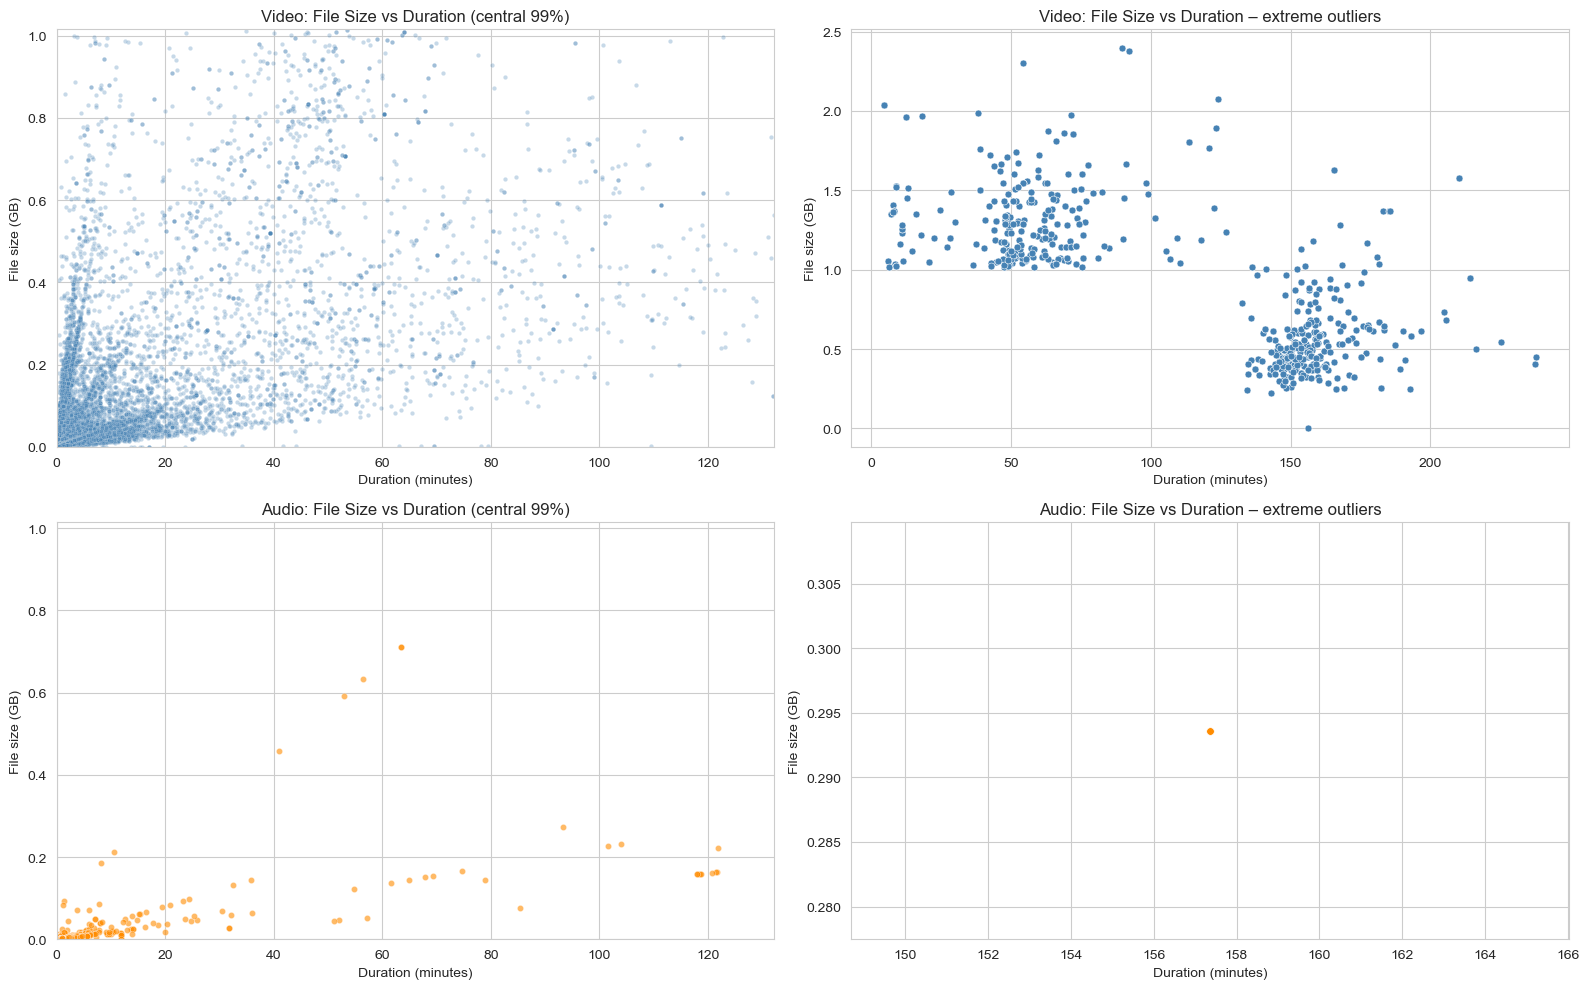

Video items: 23,523 (central: 22,924, outliers: 599)
Audio items: 7,273 (central: 7,272, outliers: 1)


In [11]:
# File size vs duration by media type, with separate views for Video and Audio
# This cell visualizes how file size and duration relate for video and audio,
# and separates the more typical items from extreme outliers using global
# percentile thresholds. Video and audio are shown in different rows so that
# audio patterns are not visually overwhelmed by the more numerous videos.

# Keep only items with non-zero duration and size so the ratios make sense
media_fd = content_service.loc[
    (content_service["duration"] > 0) & (content_service["revision_size"] > 0)
].copy()

# Convert duration to minutes and size to gigabytes for more interpretable axes
media_fd["duration_min"] = media_fd["duration"] / 60.0
media_fd["size_gb"] = media_fd["revision_size"] / (1024 ** 3)

# ---------------------------------------------------------------------------
# Define global thresholds to distinguish central cluster from extreme outliers
# ---------------------------------------------------------------------------
# Use the 99th percentile of duration and size so that:
#   - "Central" items fall within these limits on both axes
#   - "Outliers" are any items beyond these limits in either duration or size
# Using global thresholds keeps video/audio comparisons consistent.
dur_p99 = media_fd["duration_min"].quantile(0.99)
size_p99 = media_fd["size_gb"].quantile(0.99)

# ---------------------------------------------------------------------------
# Split the dataset by media type and mark central vs outlier items
# ---------------------------------------------------------------------------
# Separate video and audio items so each can be plotted on its own row
video_fd = media_fd[media_fd["type"] == "Video"].copy()
audio_fd = media_fd[media_fd["type"] == "Audio"].copy()

# For each type, mark items inside the central region vs those in the tails
video_central = video_fd[(video_fd["duration_min"] <= dur_p99) & (video_fd["size_gb"] <= size_p99)]
video_outliers = video_fd.drop(video_central.index)

audio_central = audio_fd[(audio_fd["duration_min"] <= dur_p99) & (audio_fd["size_gb"] <= size_p99)]
audio_outliers = audio_fd.drop(audio_central.index)

# ---------------------------------------------------------------------------
# Create a 2x2 grid: row 1 for video, row 2 for audio
# Each row shows the central cluster (left) and the extreme outliers (right)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ---------------------------------------------------------------------------
# Row 1: Video only (central cluster and outliers)
# ---------------------------------------------------------------------------
ax = axes[0, 0]
if not video_central.empty:
    # Central video items plotted with lighter styling to show overall trend
    sns.scatterplot(
        data=video_central,
        x="duration_min",
        y="size_gb",
        color="steelblue",
        alpha=0.3,
        s=10,
        ax=ax,
    )
    ax.set_xlim(0, dur_p99)
    ax.set_ylim(0, size_p99)
    ax.set_xlabel("Duration (minutes)")
    ax.set_ylabel("File size (GB)")
    ax.set_title("Video: File Size vs Duration (central 99%)")
else:
    ax.text(0.5, 0.5, "No video items in central region", ha="center", va="center")
    ax.axis("off")

ax = axes[0, 1]
if not video_outliers.empty:
    # Extreme video items highlighted separately to surface unusual behavior
    sns.scatterplot(
        data=video_outliers,
        x="duration_min",
        y="size_gb",
        color="steelblue",
        s=25,
        ax=ax,
    )
    ax.set_xlabel("Duration (minutes)")
    ax.set_ylabel("File size (GB)")
    ax.set_title("Video: File Size vs Duration – extreme outliers")
else:
    ax.text(0.5, 0.5, "No video items beyond 99th percentiles", ha="center", va="center")
    ax.axis("off")

# ---------------------------------------------------------------------------
# Row 2: Audio only (central cluster and outliers)
# ---------------------------------------------------------------------------
ax = axes[1, 0]
if not audio_central.empty:
    # Central audio items with a stronger color so they remain visible despite
    # being fewer in number than videos overall
    sns.scatterplot(
        data=audio_central,
        x="duration_min",
        y="size_gb",
        color="darkorange",
        alpha=0.6,
        s=20,
        ax=ax,
    )
    ax.set_xlim(0, dur_p99)
    ax.set_ylim(0, size_p99)
    ax.set_xlabel("Duration (minutes)")
    ax.set_ylabel("File size (GB)")
    ax.set_title("Audio: File Size vs Duration (central 99%)")
else:
    ax.text(0.5, 0.5, "No audio items in central region", ha="center", va="center")
    ax.axis("off")

ax = axes[1, 1]
if not audio_outliers.empty:
    # Extreme audio items; these are candidates for deeper inspection
    sns.scatterplot(
        data=audio_outliers,
        x="duration_min",
        y="size_gb",
        color="darkorange",
        s=30,
        ax=ax,
    )
    ax.set_xlabel("Duration (minutes)")
    ax.set_ylabel("File size (GB)")
    ax.set_title("Audio: File Size vs Duration – extreme outliers")
else:
    ax.text(0.5, 0.5, "No audio items beyond 99th percentiles", ha="center", va="center")
    ax.axis("off")

# Tidy the layout so subplot titles and labels do not overlap
plt.tight_layout()
plt.show()

# Print a short numeric summary to accompany the visual view
print(
    f"Video items: {len(video_fd):,} (central: {len(video_central):,}, "
    f"outliers: {len(video_outliers):,})"
)
print(
    f"Audio items: {len(audio_fd):,} (central: {len(audio_central):,}, "
    f"outliers: {len(audio_outliers):,})"
)


Potentially under-encoded items (duration >= 10 min, very low bitrate): 76 items
Median duration: 24.9 min; median bitrate: 0.13 Mb/s


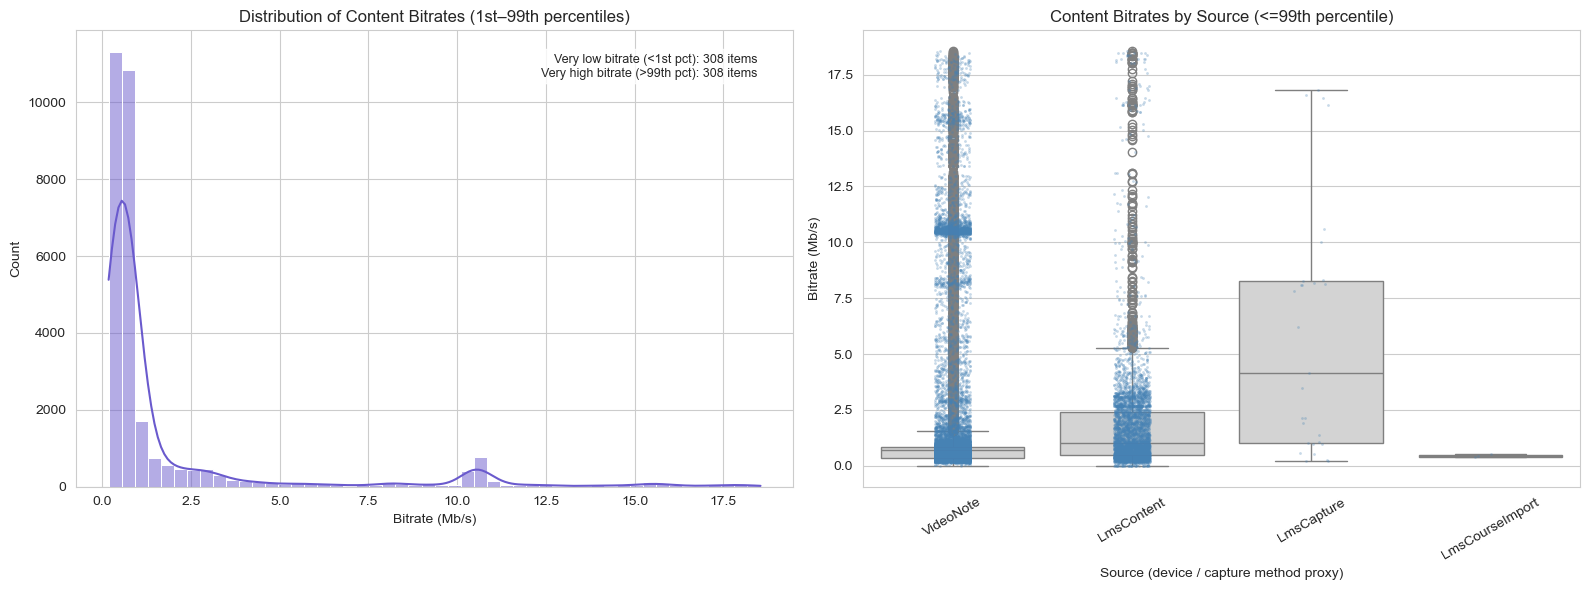

In [4]:
# Bitrate-focused views: distribution and comparison by source (device proxy)

# Start from items with non-zero size and duration so bitrate is well-defined
bitrate_df = content_service.loc[
    (content_service["duration"] > 0) & (content_service["revision_size"] > 0)
].copy()

# Compute helper columns for interpretation
bitrate_df["duration_min"] = bitrate_df["duration"] / 60.0
bitrate_df["size_mb"] = bitrate_df["revision_size"] / (1024 ** 2)
# Bitrate in megabits per second (Mb/s)
bitrate_df["bitrate_mbps"] = (
    bitrate_df["revision_size"] * 8 / bitrate_df["duration"]
) / 1e6

# Use lower / upper percentiles to separate typical items from extreme outliers
low_bitrate_p1 = bitrate_df["bitrate_mbps"].quantile(0.01)
high_bitrate_p99 = bitrate_df["bitrate_mbps"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: overall bitrate distribution (central 98%)
ax = axes[0]
central_mask = (
    (bitrate_df["bitrate_mbps"] >= low_bitrate_p1)
    & (bitrate_df["bitrate_mbps"] <= high_bitrate_p99)
)
central_bitrates = bitrate_df.loc[central_mask, "bitrate_mbps"]

sns.histplot(central_bitrates, bins=50, kde=True, color="slateblue", ax=ax)
ax.set_title("Distribution of Content Bitrates (1st–99th percentiles)")
ax.set_xlabel("Bitrate (Mb/s)")
ax.set_ylabel("Count")

# Highlight how many items fall into very low / very high bitrate tails
very_low = bitrate_df[bitrate_df["bitrate_mbps"] < low_bitrate_p1]
very_high = bitrate_df[bitrate_df["bitrate_mbps"] > high_bitrate_p99]

text = (
    f"Very low bitrate (<1st pct): {len(very_low):,} items\n"
    f"Very high bitrate (>99th pct): {len(very_high):,} items"
)
ax.text(
    0.95,
    0.95,
    text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

# Specifically flag suspiciously small files for relatively long durations
suspicious_long_low = very_low[very_low["duration_min"] >= 10]
if not suspicious_long_low.empty:
    print(
        "Potentially under-encoded items (duration >= 10 min, very low bitrate):",
        len(suspicious_long_low),
        "items",
    )
    print(
        "Median duration:", f"{suspicious_long_low['duration_min'].median():.1f}",
        "min; median bitrate:", f"{suspicious_long_low['bitrate_mbps'].median():.2f}",
        "Mb/s",
    )

# Right: compare bitrate across content sources (proxy for device/origin)
ax = axes[1]
if "source" in bitrate_df.columns:
    sns.boxplot(
        data=bitrate_df[bitrate_df["bitrate_mbps"] <= high_bitrate_p99],
        x="source",
        y="bitrate_mbps",
        ax=ax,
        color="lightgray",
    )
    sns.stripplot(
        data=bitrate_df[bitrate_df["bitrate_mbps"] <= high_bitrate_p99],
        x="source",
        y="bitrate_mbps",
        ax=ax,
        size=2,
        alpha=0.3,
        color="steelblue",
    )
    ax.set_title("Content Bitrates by Source (<=99th percentile)")
    ax.set_xlabel("Source (device / capture method proxy)")
    ax.set_ylabel("Bitrate (Mb/s)")
    ax.tick_params(axis="x", rotation=30)
else:
    ax.text(
        0.5,
        0.5,
        "No 'source' column available for bitrate-by-device view",
        ha="center",
        va="center",
    )
    ax.axis("off")

plt.tight_layout()
plt.show()
